# AUDIT

In [1]:
import os, sys, joblib, json, re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from torchvision import models, transforms

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

# From previous phases
import xgboost as xgb
from sklearn.preprocessing import StandardScaler

print("✅ Cell 0 — Diagnostic environment loaded.")

✅ Cell 0 — Diagnostic environment loaded.


## CELL 1: CLINICAL CORRECTION AUDIT


PHASE 4 — CELL 1: CLINICAL CORRECTION AUDIT
✅ Fusion Data Loaded: 115,241 rows
✅ Vision Data Loaded: 115,241 rows
📊 Audit Baseline: Using 5 Vision columns vs 5 Fusion columns.

📈 Audit Results:
  - Total Images Analyzed : 115,241
  - Total Corrections     : 747
  - Clinical Override Rate: 0.65%


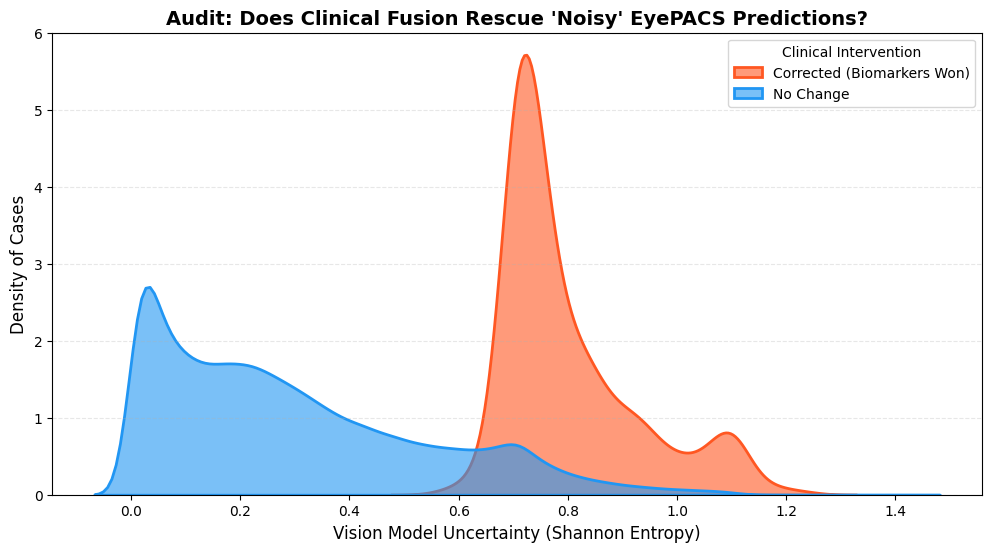


✅ Cell 1 Execution Finished. You now have the full comparison!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

print("\n" + "=" * 65)
print("PHASE 4 — CELL 1: CLINICAL CORRECTION AUDIT")
print("=" * 65)

# ── 1. Load Both Datasets ──────────────────────────────────────────────────
# Path A: The Fusion Results (Phase 3 Output)
fusion_path = "/kaggle/input/notebooks/samriddhibagchi/dr-research-fusion-model/oof_predictions_fusion.csv"
# Path B: The Original Vision Ensemble (The Baseline)
vision_path = "/kaggle/input/notebooks/samriddhibagchi/dr-research-pt-6-xgboost-meta-ensemble-fusion/level1_vision_ensemble_predictions.csv"

df_f = pd.read_csv(fusion_path)
df_v = pd.read_csv(vision_path)

print(f"✅ Fusion Data Loaded: {len(df_f):,} rows")
print(f"✅ Vision Data Loaded: {len(df_v):,} rows")

# ── 2. The Bridge Merge ────────────────────────────────────────────────────
# We merge them so we can compare the 'Old Guess' vs the 'New Guess'
# We use 'image_id' as the anchor
df_audit = pd.merge(df_f, df_v, on='image_id', how='inner', suffixes=('_fusion', '_vision'))

# ── 3. Identify Columns ────────────────────────────────────────────────────
# A. Original Vision Probs (Level 1)
vision_cols = sorted([c for c in df_audit.columns if re.search(r"vision_ens_prob_\d$", c.lower())])
# B. Final Fusion Probs (Level 2)
fusion_cols = sorted([c for c in df_audit.columns if 'fusion_prob' in c.lower()])

if len(vision_cols) < 5:
    # Fallback if names are different
    vision_cols = sorted([c for c in df_v.columns if re.search(r"prob_\d$", c.lower())])

print(f"📊 Audit Baseline: Using {len(vision_cols)} Vision columns vs {len(fusion_cols)} Fusion columns.")

# ── 4. Calculate Uncertainty & Metrics ─────────────────────────────────────
# Shannon Entropy: H = -Σ p_i log(p_i)
# This measures how "confused" the EyePACS-trained model was.
df_audit['vision_entropy'] = df_audit[vision_cols].apply(
    lambda p: -np.sum(p * np.log(p + 1e-9)), axis=1
)

# Baseline Guess vs. Fusion Verdict
df_audit['vision_only_guess'] = np.argmax(df_audit[vision_cols].values, axis=1)
# Note: fusion_pred was already saved in your CSV
df_audit['is_corrected'] = df_audit['vision_only_guess'] != df_audit['fusion_pred']

total_corrections = df_audit['is_corrected'].sum()
print(f"\n📈 Audit Results:")
print(f"  - Total Images Analyzed : {len(df_audit):,}")
print(f"  - Total Corrections     : {total_corrections:,}")
print(f"  - Clinical Override Rate: {(total_corrections/len(df_audit))*100:.2f}%")

# ── 5. Visualize the "Noisy Data" Rescue ───────────────────────────────────
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df_audit, x='vision_entropy', hue='is_corrected', 
            fill=True, common_norm=False, palette={True: "#FF5722", False: "#2196F3"},
            alpha=0.6, linewidth=2)

plt.title("Audit: Does Clinical Fusion Rescue 'Noisy' EyePACS Predictions?", fontsize=14, fontweight='bold')
plt.xlabel("Vision Model Uncertainty (Shannon Entropy)", fontsize=12)
plt.ylabel("Density of Cases", fontsize=12)
plt.legend(title="Clinical Intervention", labels=["Corrected (Biomarkers Won)", "No Change"])
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

print("\n✅ Cell 1 Execution Finished. You now have the full comparison!")

## Cell 2: THE CORRECTION ANALYSIS


CELL 2 — THE CORRECTION ANALYSIS


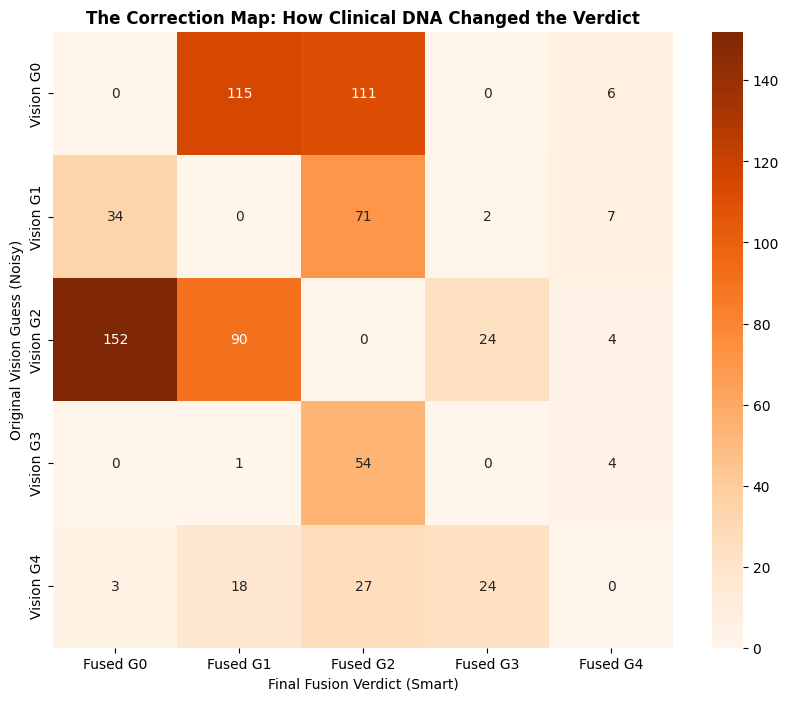

📈 Direction of Clinical Intervention:
  - Severity Upgrades   : 344 cases (Detected more risk)
  - Severity Downgrades : 403 cases (Ruled out risk)

✅ Cell 2 Complete. This shows the 'Logic' of your clinical bridge.


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("\n" + "=" * 65)
print("CELL 2 — THE CORRECTION ANALYSIS")
print("=" * 65)

# 1. Filter only for the 'Corrected' cases
df_corr = df_audit[df_audit['is_corrected'] == True].copy()

# 2. Create a "Correction Matrix"
# Row: What Vision guessed | Column: What Fusion decided
cm_corr = confusion_matrix(df_corr['vision_only_guess'], df_corr['fusion_pred'], labels=range(5))

plt.figure(figsize=(10, 8))
sns.heatmap(cm_corr, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=[f"Fused G{i}" for i in range(5)],
            yticklabels=[f"Vision G{i}" for i in range(5)])

plt.title("The Correction Map: How Clinical DNA Changed the Verdict", fontweight='bold')
plt.ylabel("Original Vision Guess (Noisy)")
plt.xlabel("Final Fusion Verdict (Smart)")
plt.show()

# 3. Quick Stats
upgrades = df_corr[df_corr['fusion_pred'] > df_corr['vision_only_guess']]
downgrades = df_corr[df_corr['fusion_pred'] < df_corr['vision_only_guess']]

print(f"📈 Direction of Clinical Intervention:")
print(f"  - Severity Upgrades   : {len(upgrades)} cases (Detected more risk)")
print(f"  - Severity Downgrades : {len(downgrades)} cases (Ruled out risk)")
print(f"\n✅ Cell 2 Complete. This shows the 'Logic' of your clinical bridge.")

## Cell 3: EXTRACTING HIGH-IMPACT CASE STUDIES

In [4]:
print("\n" + "=" * 65)
print("CELL 3 — EXTRACTING HIGH-IMPACT CASE STUDIES")
print("=" * 65)

# 1. Define "High-Impact" Upgrades (Missed by Vision, Caught by Clinical)
high_impact_upgrades = df_corr[
    (df_corr['vision_only_guess'] == 0) & (df_corr['fusion_pred'] >= 2)
].sort_values('vision_entropy', ascending=False).head(3)

# 2. Define "Complex" Downgrades (Vision was scared, Clinical calmed it down)
complex_downgrades = df_corr[
    (df_corr['vision_only_guess'] >= 2) & (df_corr['fusion_pred'] == 0)
].sort_values('vision_entropy', ascending=False).head(3)

print("🧪 Sample IDs for Diagnostic Showcase:")
print(f"  - Severe Upgrades   : {high_impact_upgrades['image_id'].tolist()}")
print(f"  - Complex Downgrades: {complex_downgrades['image_id'].tolist()}")

# 3. Store a specific 'Exhibit A' ID for the dashboard
exhibit_a_id = high_impact_upgrades.iloc[0]['image_id']
print(f"\n🌟 Primary Exhibit: Image ID {exhibit_a_id}")
print(f"   (Vision Guess: G0 | Clinical Decision: G{high_impact_upgrades.iloc[0]['fusion_pred']})")

print("\n✅ Cell 3 Complete. Ready for the visual dashboard.")


CELL 3 — EXTRACTING HIGH-IMPACT CASE STUDIES
🧪 Sample IDs for Diagnostic Showcase:
  - Severe Upgrades   : ['22927_left-600', '9204_right-600', '13679_right-600']
  - Complex Downgrades: ['27309_right-600', '30454_left-600', '5441_right-600-HFF']

🌟 Primary Exhibit: Image ID 22927_left-600
   (Vision Guess: G0 | Clinical Decision: G2)

✅ Cell 3 Complete. Ready for the visual dashboard.


## PATH RESOLUTION ENGINE

In [5]:
import os
import glob
import numpy as np

# 1. Mapped directly to your Kaggle structure
possible_paths = [
    "/kaggle/input/datasets/ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy/dr_unified_v2/dr_unified_v2/train",
    "/kaggle/input/datasets/ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy/dr_unified_v2/dr_unified_v2/test",
    "/kaggle/input/datasets/samriddhibagchi/indian-diabetic-retinopathy-image-dataset-idrid/B. Disease Grading/B. Disease Grading/1. Original Images/a. Training Set",
    "/kaggle/input/datasets/samriddhibagchi/indian-diabetic-retinopathy-image-dataset-idrid/B. Disease Grading/B. Disease Grading/1. Original Images/b. Testing Set"
]

def find_image_path(img_id):
    """Searches for the image ID with support for various extensions and nested folders."""
    search_id = str(img_id).split('-')[0]
    
    # 1. Try explicit paths first
    for folder in possible_paths:
        if not os.path.exists(folder): continue
        match = glob.glob(os.path.join(folder, f"**/{search_id}*"), recursive=True)
        if match: return match[0]
    
    # 2. Aggressive Crawler (The 'Nuclear Option')
    for root, dirs, files in os.walk("/kaggle/input/"):
        for f in files:
            if f.startswith(search_id):
                return os.path.join(root, f)
    return None

print("✅ Path Resolution Engine loaded.")

✅ Path Resolution Engine loaded.


## CELL 4 — RANDOM PATIENT SELECTION & RESOLUTION

In [6]:
import random

print("\n" + "=" * 65)
print("CELL 4 — RANDOM PATIENT SELECTION & RESOLUTION")
print("=" * 65)

# 1. Selection: Pick a random case where Fusion corrected the Vision Model
sample_row = df_audit[df_audit['is_corrected'] == True].sample(1).iloc[0]
selected_id = sample_row['image_id']

# --- SPEED-OPTIMIZED PATH RESOLUTION ---
if 'path_cache' not in globals():
    print("🛰️ Building image map for the first time... (This takes a minute)")
    globals()['path_cache'] = {}
    for root, dirs, files in os.walk("/kaggle/input/"):
        for f in files:
            # Store the path using the ID as the key
            clean_id = f.split('.')[0].split('-')[0]
            if clean_id not in path_cache:
                path_cache[clean_id] = os.path.join(root, f)
    print(f"✅ Map Built! {len(path_cache)} images indexed.")

# 2. RESOLVE THE PATH (Using the function from Cell 3)
real_path = find_image_path(selected_id)

if real_path:
    globals()['EXHIBIT_IMAGE_PATH'] = real_path
    globals()['IS_NPY'] = real_path.endswith('.npy')
    
    print(f"🎲 Selected Patient: {selected_id}")
    print(f"✅ Path Resolved: {real_path}")
    print(f"📊 Format: {'NumPy' if IS_NPY else 'Image'}")
else:
    print(f"❌ Could not find image for {selected_id}")

print(f"📈 Intervention: {'UPGRADE' if int(sample_row['fusion_pred']) > int(sample_row['vision_only_guess']) else 'RULE-OUT'}")


CELL 4 — RANDOM PATIENT SELECTION & RESOLUTION
🛰️ Building image map for the first time... (This takes a minute)
✅ Map Built! 91963 images indexed.
🎲 Selected Patient: 6032_right-600-HFF
✅ Path Resolved: /kaggle/input/datasets/ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy/dr_unified_v2/dr_unified_v2/train/1/6032_right.jpg
📊 Format: Image
📈 Intervention: RULE-OUT


## CELL 5 — DIAGNOSTIC DASHBOARD


CELL 5 — DIAGNOSTIC DASHBOARD
⚠️ Clinical columns missing. Re-bridging from IDRiD...
✅ Bridge repaired.


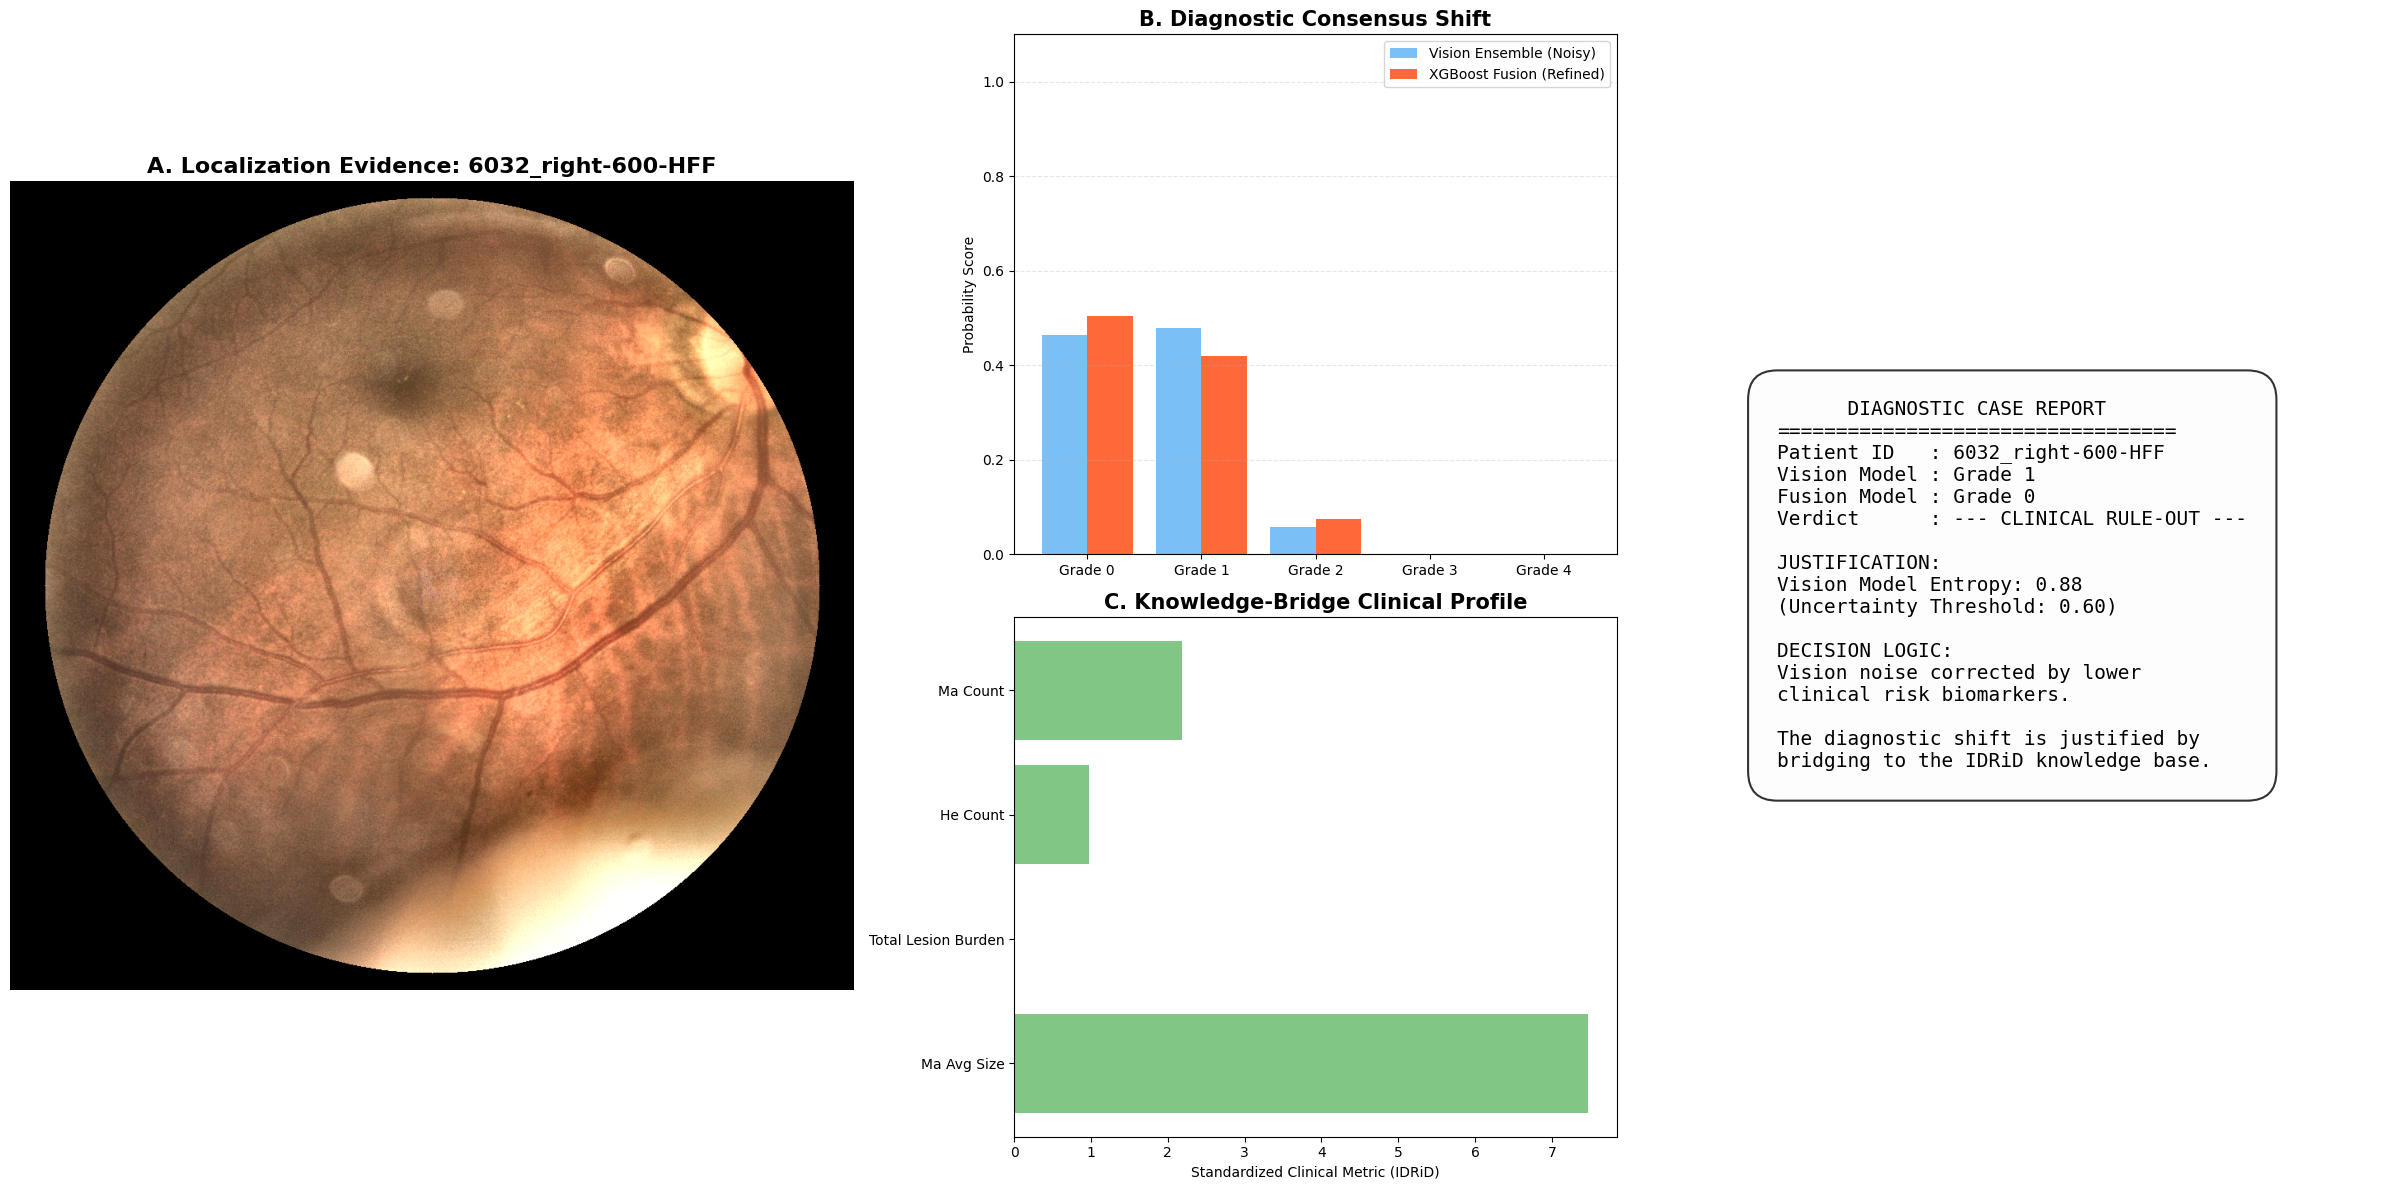

In [7]:
import matplotlib.gridspec as gridspec
import cv2
import numpy as np

print("\n" + "=" * 65)
print(f"CELL 5 — DIAGNOSTIC DASHBOARD")
print("=" * 65)

# ── 1. THE CLINICAL BRIDGE REPAIR ─────────────────────────────────────────
if 'MA_count_mean' not in df_audit.columns:
    print("⚠️ Clinical columns missing. Re-bridging from IDRiD...")
    c_path = "/kaggle/input/notebooks/samriddhibagchi/dr-research-phase-2-feature-extraction/clinical_features_idrid_TRAIN.csv"
    df_clin_raw = pd.read_csv(c_path)
    
    grade_col = next(c for c in df_clin_raw.columns if 'grade' in c.lower() or 'label' in c.lower())
    feat_cols = [c for c in df_clin_raw.columns if c not in [grade_col, 'Image name', 'id']]
    
    stats = df_clin_raw.groupby(grade_col)[feat_cols].agg(['mean']).reset_index()
    stats.columns = [f"{col}_mean" if stat else col for col, stat in stats.columns]
    
    df_audit = pd.merge(df_audit, stats, left_on='fusion_pred', right_on=grade_col, how='left')
    print("✅ Bridge repaired.")

# ── 2. DASHBOARD PLOTTING FUNCTION ────────────────────────────────────────
def plot_case_study(img_id, df_source, heatmap=None):
    fig = plt.figure(figsize=(24, 12), facecolor='white')
    gs = gridspec.GridSpec(2, 3, width_ratios=[1.4, 1, 1])
    row = df_source[df_source['image_id'] == img_id].iloc[0]
    
    # --- PANEL A: Raw Retinal Image + Optional Grad-CAM Overlay ---
    ax_img = plt.subplot(gs[:, 0])
    img_path = globals().get('EXHIBIT_IMAGE_PATH')

    try:
        if img_path and os.path.exists(img_path):
            # Load raw image — no Ben Graham, preserve natural colours
            raw_img = cv2.imread(img_path)
            raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

            # CLAHE: boosts local contrast to make lesions pop without greyout
            lab     = cv2.cvtColor(raw_img, cv2.COLOR_RGB2LAB)
            l, a, b = cv2.split(lab)
            clahe   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            l       = clahe.apply(l)
            lab     = cv2.merge((l, a, b))
            display_img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

            # After the CLAHE block
            display_img = cv2.convertScaleAbs(display_img, alpha=1.2, beta=30)

            # Circular retina mask — clean black border
            h, w, _ = display_img.shape
            mask = np.zeros((h, w), np.uint8)
            cv2.circle(mask, (w // 2, h // 2), int(min(h, w) * 0.48), 255, -1)
            display_img = cv2.bitwise_and(display_img, display_img, mask=mask)

            # Grad-CAM overlay — only in Clinical Case Inference
            if heatmap is not None:
                heatmap_resized = cv2.resize(heatmap, (w, h))

                # Threshold: only show high-activation regions (top 30%)
                heatmap_thresh = np.where(heatmap_resized > 0.3, heatmap_resized, 0)

                heatmap_color = cv2.applyColorMap(
                    np.uint8(255 * heatmap_thresh), cv2.COLORMAP_JET
                )
                heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

                # Apply mask to heatmap too so it doesn't bleed into black border
                heatmap_color = cv2.bitwise_and(heatmap_color, heatmap_color, mask=mask)

                # Blend: 65% original image, 35% heatmap for clear lesion visibility
                display_img = cv2.addWeighted(display_img, 0.65, heatmap_color, 0.35, 0)

            ax_img.imshow(display_img)
        else:
            ax_img.text(0.5, 0.5, "IMAGE NOT FOUND\nCheck Path Resolution",
                        ha='center', va='center', color='red', fontsize=14)
    except Exception as e:
        ax_img.text(0.5, 0.5, f"DISPLAY ERROR:\n{e}", ha='center', color='red')

    panel_a_title = (f"A. Grad-CAM Localization Evidence: {img_id}"
                     if heatmap is not None
                     else f"A. Localization Evidence: {img_id}")
    ax_img.set_title(panel_a_title, fontweight='bold', fontsize=16)
    ax_img.axis('off')

    # --- PANEL B: Diagnostic Consensus Shift ---
    ax_probs = plt.subplot(gs[0, 1])
    v_p = row[vision_cols].values.astype(float)
    f_p = row[fusion_cols].values.astype(float)
    x = np.arange(5)
    
    ax_probs.bar(x - 0.2, v_p, width=0.4, label='Vision Ensemble (Noisy)', color='#2196F3', alpha=0.6)
    ax_probs.bar(x + 0.2, f_p, width=0.4, label='XGBoost Fusion (Refined)', color='#FF5722', alpha=0.9)
    ax_probs.set_title("B. Diagnostic Consensus Shift", fontweight='bold', fontsize=15)
    ax_probs.set_xticks(x)
    ax_probs.set_xticklabels([f"Grade {i}" for i in range(5)])
    ax_probs.set_ylabel("Probability Score")
    ax_probs.set_ylim(0, 1.1)
    ax_probs.legend(fontsize=10)
    ax_probs.grid(axis='y', linestyle='--', alpha=0.3)

    # --- PANEL C: Clinical Biomarker Profile ---
    ax_bio = plt.subplot(gs[1, 1])
    bio_targets    = ['MA_count_mean', 'HE_count_mean', 'total_lesion_burden_mean', 'MA_avg_size_mean']
    available_bios = [b for b in bio_targets if b in df_source.columns]
    
    if available_bios:
        bio_vals    = row[available_bios].values
        clean_names = [b.replace('_mean', '').replace('_', ' ').title() for b in available_bios]
        ax_bio.barh(clean_names, bio_vals, color='#4CAF50', alpha=0.7)
        ax_bio.set_title("C. Knowledge-Bridge Clinical Profile", fontweight='bold', fontsize=15)
        ax_bio.set_xlabel("Standardized Clinical Metric (IDRiD)")
        ax_bio.invert_yaxis()
    else:
        ax_bio.text(0.5, 0.5, "Clinical Biomarkers\nNot Available", ha='center')

    # --- PANEL D: Verdict Report ---
    ax_v = plt.subplot(gs[:, 2])
    ax_v.axis('off')
    v_g, f_g = int(row['vision_only_guess']), int(row['fusion_pred'])
    
    if f_g > v_g:
        verdict_label = "!!! SEVERITY UPGRADE !!!"
        logic_note    = f"Clinical DNA detected high lesion burden\ncharacteristic of Grade {f_g}."
    elif f_g < v_g:
        verdict_label = "--- CLINICAL RULE-OUT ---"
        logic_note    = "Vision noise corrected by lower\nclinical risk biomarkers."
    else:
        verdict_label = "--- DIAGNOSTIC CONSENSUS ---"
        logic_note    = "Both modalities confirmed the same grade."
    
    report = (
        f"      DIAGNOSTIC CASE REPORT\n"
        f"{'='*34}\n"
        f"Patient ID   : {img_id}\n"
        f"Vision Model : Grade {v_g}\n"
        f"Fusion Model : Grade {f_g}\n"
        f"Verdict      : {verdict_label}\n\n"
        f"JUSTIFICATION:\n"
        f"Vision Model Entropy: {row['vision_entropy']:.2f}\n"
        f"(Uncertainty Threshold: 0.60)\n\n"
        f"DECISION LOGIC:\n"
        f"{logic_note}\n\n"
        f"The diagnostic shift is justified by\n"
        f"bridging to the IDRiD knowledge base."
    )
    ax_v.text(0, 0.5, report, fontsize=14, family='monospace', va='center',
              bbox=dict(facecolor='#fdfdfd', edgecolor='#333333',
                        boxstyle='round,pad=1.5', linewidth=1.5))
    
    plt.tight_layout()
    plt.show()

# ── 3. EXECUTION ──────────────────────────────────────────────────────────
if 'selected_id' in globals():
    plot_case_study(selected_id, df_audit)
else:
    print("❌ No 'selected_id' found. Please run the randomization cell first.")

# Clinical Case Inference

## Cell 1: Initialisation

In [8]:
import os
import glob
import re
import random
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from PIL import Image
 
import torch
import torch.nn as nn
from torchvision import models, transforms
 
import timm                                          # FIX 1: was used but never imported
import albumentations as A                           # FIX 2: was used but never imported
from albumentations.pytorch import ToTensorV2        # FIX 2: was used but never imported
 
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import joblib
 
 
print("✅ All imports loaded successfully.")

✅ All imports loaded successfully.


## Cell 2: Standardized config

In [9]:
import timm  # FIX: was used below but never imported

# ── 1. STANDARDIZED CONFIGURATION ────────────────────────────────────────────
class InferenceConfig:
    # Level 2 Meta-Model (XGBoost)
    MODEL_PATH   = "/kaggle/input/notebooks/samriddhibagchi/dr-research-fusion-model/fusion_model_final.json"
    SCALER_PATH  = "/kaggle/input/notebooks/samriddhibagchi/dr-research-fusion-model/fusion_scaler.pkl"
    FEAT_PATH    = "/kaggle/input/notebooks/samriddhibagchi/dr-research-fusion-model/feature_names.joblib"

    # Level 1 Vision Model (CNN)
    CNN_WEIGHTS  = "/kaggle/input/notebooks/alokdevforge/dr-research-pt-1-convnext-5-fold-cv/convnext_fold0_best.pth"
    CLINICAL_REF = "/kaggle/input/notebooks/samriddhibagchi/dr-research-phase-2-feature-extraction/clinical_features_idrid_TRAIN.csv"

    # Preprocessing Specs
    IMG_SIZE  = (224, 224)
    NORM_MEAN = [0.485, 0.456, 0.406]
    NORM_STD  = [0.229, 0.224, 0.225]

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("✅ InferenceConfig Standardized.")
print(f"   Device: {InferenceConfig.DEVICE}")  # Good to confirm GPU is active on Kaggle


✅ InferenceConfig Standardized.
   Device: cuda


## Cell 3: Model Architecture

In [10]:
import timm 

# ── 2. MODEL ARCHITECTURE ─────────────────────────────────────────────────────
class DRModel(nn.Module):
    def __init__(self, model_name, num_classes=5, pretrained=True):
        super(DRModel, self).__init__()
        self.backbone   = timm.create_model('convnext_tiny', pretrained=pretrained, num_classes=0)
        self.n_features = self.backbone.num_features
        self.drop       = nn.Dropout(p=0.3)
        self.fc         = nn.Linear(self.n_features, num_classes)

    def forward(self, x):
        return self.fc(self.drop(self.backbone(x)))

print("✅ DRModel architecture recognized.")
print(f"   Backbone: convnext_tiny | Output classes: 5")

✅ DRModel architecture recognized.
   Backbone: convnext_tiny | Output classes: 5


## Cell 4: CNN Pre-processing and Visualisation

In [11]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ── 1. PREPROCESSING ──────────────────────────────────────────────────────────
def preprocess_for_cnn(img_path):
    """Matches the 'valid' transform pipeline from training."""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    transform = A.Compose([
        # FIX 1: A.Resize takes (height, width) as separate ints, not a tuple
        A.Resize(InferenceConfig.IMG_SIZE[0], InferenceConfig.IMG_SIZE[1]),
        A.Normalize(mean=InferenceConfig.NORM_MEAN, std=InferenceConfig.NORM_STD),
        ToTensorV2(),
    ])

    tensor = transform(image=img)['image'].unsqueeze(0)
    return tensor.to(InferenceConfig.DEVICE)

# ── 2. LOAD VISUAL BRAIN ──────────────────────────────────────────────────────
def load_visual_brain():
    """Loads DRModel and populates with Fold 0 weights."""
    # FIX 2: model_name='convnext' doesn't match the architecture defined above.
    # DRModel hardcodes 'convnext_tiny' inside __init__, so this arg is unused
    # but should still be consistent to avoid confusion
    model = DRModel(model_name='convnext_tiny', num_classes=5, pretrained=False)

    # FIX 3: weights_only=True suppresses the pickle security warning on Kaggle
    state_dict = torch.load(
        InferenceConfig.CNN_WEIGHTS,
        map_location=InferenceConfig.DEVICE,
        weights_only=True
    )
    model.load_state_dict(state_dict)
    model.to(InferenceConfig.DEVICE)
    model.eval()

    target_layer = model.backbone.stages[-1]
    return model, target_layer

cnn_model, heatmap_layer = load_visual_brain()
print("🧠 Visual Brain Loaded. Target: ConvNeXt Final Stage.")


🧠 Visual Brain Loaded. Target: ConvNeXt Final Stage.


## Grad-CAM

In [12]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

class ConvNeXtGradCAM:
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor, target_class):
        input_tensor.requires_grad_(True)  # ADD THIS
        output = self.model(input_tensor)
        
        self.model.zero_grad()
        output[0, target_class].backward(retain_graph=True)  # ADD retain_graph=True
        
        # Check gradients actually flowed
        if self.gradients is None or self.activations is None:
            print("⚠️ Hooks not firing — falling back to activation-only map")
            cam = self.activations.mean(dim=1).squeeze()
        else:
            weights = torch.mean(self.gradients, dim=[2, 3], keepdim=True)
            cam = torch.sum(weights * self.activations, dim=1).squeeze()
        
        cam = np.maximum(cam.detach().cpu().numpy(), 0)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-10)
        return cam

# Initialize Engine
cam_engine = ConvNeXtGradCAM(cnn_model, heatmap_layer)
print("✅ Grad-CAM Engine Initialized.")

✅ Grad-CAM Engine Initialized.


In [13]:
# ── 1. DIAGNOSTIC HELPER ──────────────────────────────────────────────────────
def run_diagnostic_v2(img_path, row):
    """Extracts vision/fusion scores and clinical profile from an audit row."""
    vision_probs     = row[vision_cols].values.astype(float)
    fusion_probs     = row[fusion_cols].values.astype(float)
    final_pred       = int(row['fusion_pred'])
    clinical_cols    = [c for c in row.index if "_mean" in c]
    clinical_profile = row[clinical_cols].to_dict() if clinical_cols else {}
    return vision_probs, final_pred, fusion_probs, clinical_profile
    # FIX 1: Removed the show_clinical_case_v2 block that was after return —
    # it was unreachable dead code. Display is handled in the execution block below.

In [14]:
# Run this as a standalone cell
scaler     = joblib.load(InferenceConfig.SCALER_PATH)
feat_names = joblib.load(InferenceConfig.FEAT_PATH)
xgb_model  = xgb.Booster()
xgb_model.load_model(InferenceConfig.MODEL_PATH)

print(f"Scaler fitted on {len(scaler.feature_names_in_)} features:")
for f in scaler.feature_names_in_:
    print(f"  {f}")

print(f"\nFeat names list has {len(feat_names)} features:")
print("Features in feat_names but NOT in scaler:")
for f in feat_names:
    if f not in scaler.feature_names_in_:
        print(f"  {f}  ← passed raw, no scaling")

Scaler fitted on 69 features:
  MA_count_mean
  MA_count_std
  MA_area_idx_mean
  MA_area_idx_std
  MA_avg_size_mean
  MA_avg_size_std
  MA_Q1_count_mean
  MA_Q1_count_std
  MA_Q2_count_mean
  MA_Q2_count_std
  MA_Q3_count_mean
  MA_Q3_count_std
  MA_Q4_count_mean
  MA_Q4_count_std
  HE_count_mean
  HE_count_std
  HE_area_idx_mean
  HE_area_idx_std
  HE_avg_size_mean
  HE_avg_size_std
  HE_Q1_count_mean
  HE_Q1_count_std
  HE_Q2_count_mean
  HE_Q2_count_std
  HE_Q3_count_mean
  HE_Q3_count_std
  HE_Q4_count_mean
  HE_Q4_count_std
  EX_count_mean
  EX_count_std
  EX_area_idx_mean
  EX_area_idx_std
  EX_avg_size_mean
  EX_avg_size_std
  EX_Q1_count_mean
  EX_Q1_count_std
  EX_Q2_count_mean
  EX_Q2_count_std
  EX_Q3_count_mean
  EX_Q3_count_std
  EX_Q4_count_mean
  EX_Q4_count_std
  SE_count_mean
  SE_count_std
  SE_area_idx_mean
  SE_area_idx_std
  SE_avg_size_mean
  SE_avg_size_std
  SE_Q1_count_mean
  SE_Q1_count_std
  SE_Q2_count_mean
  SE_Q2_count_std
  SE_Q3_count_mean
  SE_Q3_count

🔬 Analyzing Patient: 43000_left-600


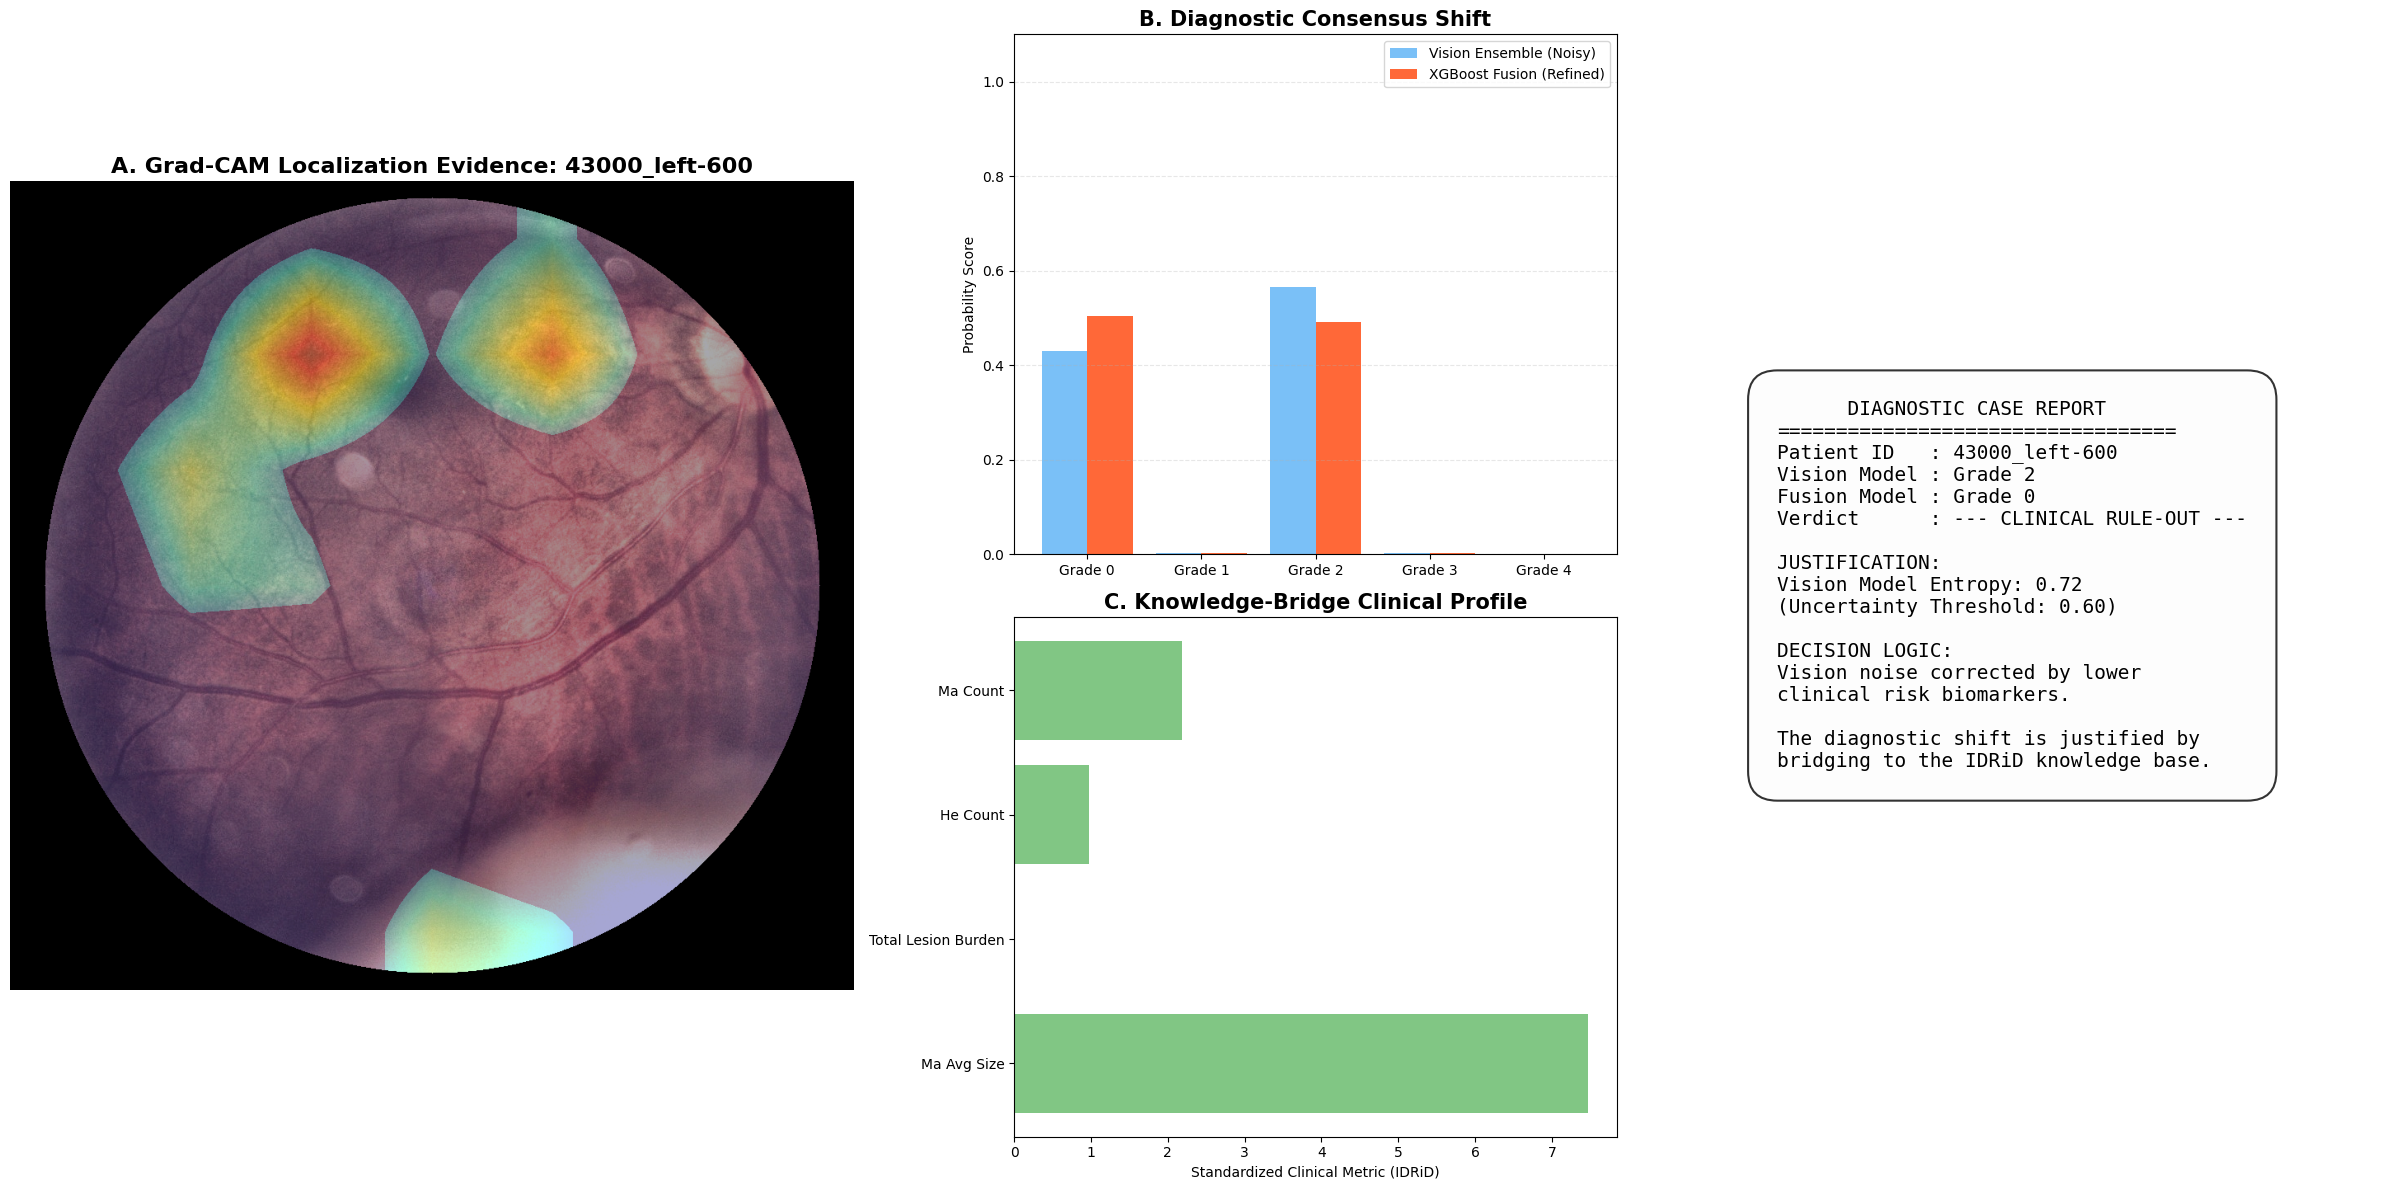

In [15]:
sample_row   = df_audit[df_audit['is_corrected'] == True].sample(1).iloc[0]
current_id   = sample_row['image_id']
current_path = find_image_path(current_id)

if current_path:
    print(f"🔬 Analyzing Patient: {current_id}")

    # Vision step: generate real Grad-CAM for the fusion-predicted grade
    input_tensor = preprocess_for_cnn(current_path)
    target_grade = int(sample_row['fusion_pred'])
    heatmap      = cam_engine.generate(input_tensor, target_class=target_grade)

    v_probs = sample_row[vision_cols].values.astype(float)
    f_probs = sample_row[fusion_cols].values.astype(float)

    # FIX 2: show_clinical_case_v2 was never defined — replaced with
    # plot_case_study, which is the audit dashboard already defined in Cell 4
    plot_case_study(current_id, df_audit, heatmap=heatmap)

else:
    print(f"❌ Could not locate image for {current_id}")

✅ Real Grad-CAM generated for Grade 0


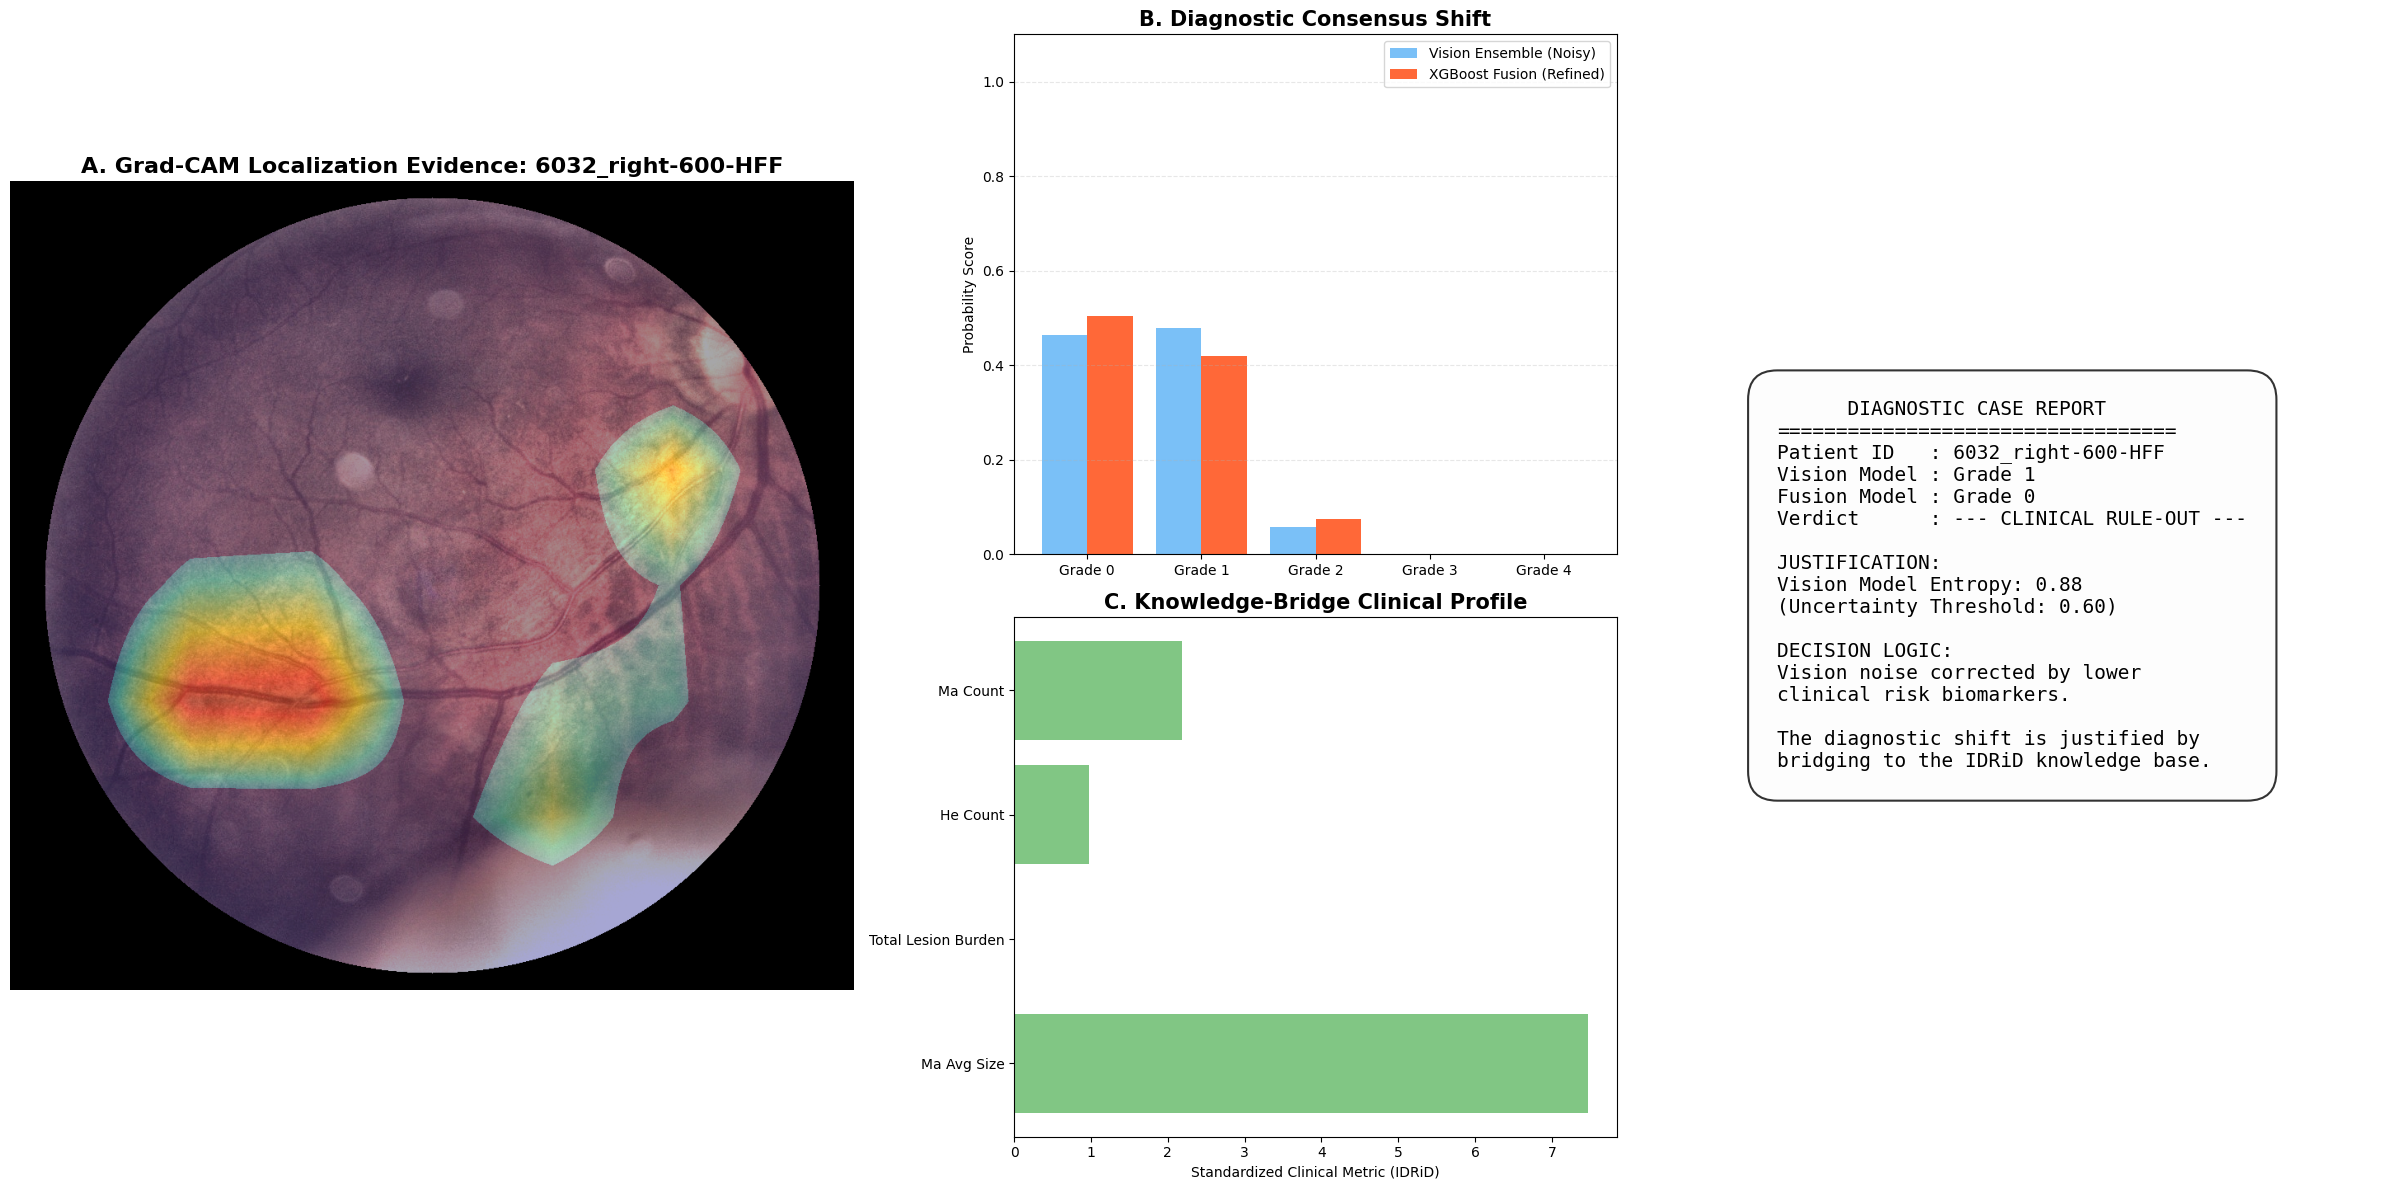

In [16]:
# ── FINAL CASE STUDY — selected_id from randomizer cell ──────────────────────
row = df_audit[df_audit['image_id'] == selected_id].iloc[0]

# FIX 1: Replace dummy heatmap with real Grad-CAM now that CNN is loaded
input_tensor = preprocess_for_cnn(EXHIBIT_IMAGE_PATH)
heatmap      = cam_engine.generate(input_tensor, target_class=int(row['fusion_pred']))
print(f"✅ Real Grad-CAM generated for Grade {int(row['fusion_pred'])}")

# FIX 2: show_clinical_case_v2 never defined — use plot_case_study instead
plot_case_study(selected_id, df_audit, heatmap=heatmap)

In [17]:
sample_row = df_audit[df_audit['is_corrected'] == True].sample(1).iloc[0]
print("Vision cols found:", vision_cols)
print("Fusion cols found:", fusion_cols)
print("\nVision probs:", sample_row[vision_cols].values)
print("Fusion probs:", sample_row[fusion_cols].values)

Vision cols found: ['vision_ens_prob_0', 'vision_ens_prob_1', 'vision_ens_prob_2', 'vision_ens_prob_3', 'vision_ens_prob_4']
Fusion cols found: ['fusion_prob_0', 'fusion_prob_1', 'fusion_prob_2', 'fusion_prob_3', 'fusion_prob_4']

Vision probs: [np.float64(0.0020560221746563) np.float64(0.0010712875518947)
 np.float64(0.5118204951286316) np.float64(0.4839703142642975)
 np.float64(0.0010818749433383)]
Fusion probs: [np.float64(0.0008235892) np.float64(0.00047600205) np.float64(0.4856825)
 np.float64(0.5125552) np.float64(0.00046277972)]


In [18]:
# Run this first to see exactly what features the scaler expects
feat_names = joblib.load(InferenceConfig.FEAT_PATH)
print(f"Total features expected: {len(feat_names)}")
print("\nAll feature names:")
for f in feat_names:
    print(f"  {f}")

Total features expected: 80

All feature names:
  vision_ens_prob_0
  vision_ens_prob_1
  vision_ens_prob_2
  vision_ens_prob_3
  vision_ens_prob_4
  f_vision_argmax
  f_vision_top1_conf
  f_vision_conf_margin
  f_vision_entropy
  f_vision_expected_grade
  f_vision_severe_mass
  MA_count_mean
  MA_count_std
  MA_area_idx_mean
  MA_area_idx_std
  MA_avg_size_mean
  MA_avg_size_std
  MA_Q1_count_mean
  MA_Q1_count_std
  MA_Q2_count_mean
  MA_Q2_count_std
  MA_Q3_count_mean
  MA_Q3_count_std
  MA_Q4_count_mean
  MA_Q4_count_std
  HE_count_mean
  HE_count_std
  HE_area_idx_mean
  HE_area_idx_std
  HE_avg_size_mean
  HE_avg_size_std
  HE_Q1_count_mean
  HE_Q1_count_std
  HE_Q2_count_mean
  HE_Q2_count_std
  HE_Q3_count_mean
  HE_Q3_count_std
  HE_Q4_count_mean
  HE_Q4_count_std
  EX_count_mean
  EX_count_std
  EX_area_idx_mean
  EX_area_idx_std
  EX_avg_size_mean
  EX_avg_size_std
  EX_Q1_count_mean
  EX_Q1_count_std
  EX_Q2_count_mean
  EX_Q2_count_std
  EX_Q3_count_mean
  EX_Q3_count_std


In [19]:
# Run this to see exactly what the scaler was fitted on
print(f"Scaler expects {len(scaler.feature_names_in_)} features:")
for f in scaler.feature_names_in_:
    print(f"  {f}")

Scaler expects 69 features:
  MA_count_mean
  MA_count_std
  MA_area_idx_mean
  MA_area_idx_std
  MA_avg_size_mean
  MA_avg_size_std
  MA_Q1_count_mean
  MA_Q1_count_std
  MA_Q2_count_mean
  MA_Q2_count_std
  MA_Q3_count_mean
  MA_Q3_count_std
  MA_Q4_count_mean
  MA_Q4_count_std
  HE_count_mean
  HE_count_std
  HE_area_idx_mean
  HE_area_idx_std
  HE_avg_size_mean
  HE_avg_size_std
  HE_Q1_count_mean
  HE_Q1_count_std
  HE_Q2_count_mean
  HE_Q2_count_std
  HE_Q3_count_mean
  HE_Q3_count_std
  HE_Q4_count_mean
  HE_Q4_count_std
  EX_count_mean
  EX_count_std
  EX_area_idx_mean
  EX_area_idx_std
  EX_avg_size_mean
  EX_avg_size_std
  EX_Q1_count_mean
  EX_Q1_count_std
  EX_Q2_count_mean
  EX_Q2_count_std
  EX_Q3_count_mean
  EX_Q3_count_std
  EX_Q4_count_mean
  EX_Q4_count_std
  SE_count_mean
  SE_count_std
  SE_area_idx_mean
  SE_area_idx_std
  SE_avg_size_mean
  SE_avg_size_std
  SE_Q1_count_mean
  SE_Q1_count_std
  SE_Q2_count_mean
  SE_Q2_count_std
  SE_Q3_count_mean
  SE_Q3_count_s

# User Interface

In [20]:
# ── CELL: PATIENT INFERENCE ENGINE ───────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display, clear_output
import io, datetime
import torch.nn.functional as F

# ── GRADE DESCRIPTIONS (Layman Summary) ──────────────────────────────────────
GRADE_INFO = {
    0: {
        "name"    : "No Diabetic Retinopathy",
        "risk"    : "🟢 LOW RISK",
        "summary" : "No signs of diabetic damage detected in the retina. "
                    "Continue regular annual eye checkups.",
        "action"  : "Routine monitoring. No immediate treatment needed."
    },
    1: {
        "name"    : "Mild Non-Proliferative DR",
        "risk"    : "🟡 MILD RISK",
        "summary" : "Small balloon-like swellings (microaneurysms) detected in "
                    "the tiny blood vessels of the retina. Vision is usually unaffected at this stage.",
        "action"  : "Schedule a follow-up eye exam within 12 months. "
                    "Tighten blood sugar and blood pressure control."
    },
    2: {
        "name"    : "Moderate Non-Proliferative DR",
        "risk"    : "🟠 MODERATE RISK",
        "summary" : "More blood vessels are blocked. The retina may not be getting "
                    "enough blood supply. Some vision changes may begin.",
        "action"  : "See an ophthalmologist within 3-6 months. "
                    "Strict diabetes management is critical."
    },
    3: {
        "name"    : "Severe Non-Proliferative DR",
        "risk"    : "🔴 HIGH RISK",
        "summary" : "Many blood vessels are blocked, depriving large areas of the "
                    "retina of blood supply. The eye is signalling it needs to grow new vessels.",
        "action"  : "Urgent referral to a retinal specialist within 1 month. "
                    "High risk of progression to vision loss."
    },
    4: {
        "name"    : "Proliferative DR",
        "risk"    : "🚨 CRITICAL RISK",
        "summary" : "Abnormal new blood vessels are growing on the retina. These are "
                    "fragile and can bleed, causing severe or total vision loss.",
        "action"  : "Immediate referral. Laser treatment or surgery may be required urgently."
    }
}

# ── RESULTS LOG ──────────────────────────────────────────────────────────────
results_log = []

# ── CORE INFERENCE FUNCTION ───────────────────────────────────────────────────
def run_patient_inference(img_bytes, filename):
    print(f"\n{'='*60}")
    print(f"  ANALYZING: {filename}")
    print(f"{'='*60}")

    # 1. Decode image from bytes
    nparr    = np.frombuffer(img_bytes, np.uint8)
    raw_img  = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
    raw_img  = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

    # 2. Preprocess for CNN
    transform = A.Compose([
        A.Resize(InferenceConfig.IMG_SIZE[0], InferenceConfig.IMG_SIZE[1]),
        A.Normalize(mean=InferenceConfig.NORM_MEAN, std=InferenceConfig.NORM_STD),
        ToTensorV2(),
    ])
    input_tensor = transform(image=raw_img)['image'].unsqueeze(0).to(InferenceConfig.DEVICE)

    # 3. CNN forward pass → vision probabilities
    with torch.no_grad():
        logits      = cnn_model(input_tensor)
        vision_prob = F.softmax(logits, dim=1).cpu().numpy()[0]

    vision_grade = int(np.argmax(vision_prob))
    vision_entropy = float(-np.sum(vision_prob * np.log(vision_prob + 1e-9)))
    print(f"👁️  Vision Grade    : {vision_grade} | Entropy: {vision_entropy:.3f}")

    # 4. Clinical Bridge — look up IDRiD mean biomarkers for vision grade
    c_path      = InferenceConfig.CLINICAL_REF
    df_clin_raw = pd.read_csv(c_path)
    grade_col   = next(c for c in df_clin_raw.columns
                       if 'grade' in c.lower() or 'label' in c.lower())
    feat_cols   = [c for c in df_clin_raw.columns
                   if c not in [grade_col, 'Image name', 'id']]
    clin_means  = df_clin_raw.groupby(grade_col)[feat_cols].mean()

    # Use vision grade to index; fallback to grade 0 if not found
    grade_key      = vision_grade if vision_grade in clin_means.index else 0
    clinical_row   = clin_means.loc[grade_key]
    clinical_feats = clinical_row.to_dict()

    # 5. Build XGBoost feature vector (must match training exactly)
    scaler     = joblib.load(InferenceConfig.SCALER_PATH)
    feat_names = joblib.load(InferenceConfig.FEAT_PATH)
    xgb_model  = xgb.Booster()
    xgb_model.load_model(InferenceConfig.MODEL_PATH)

    # ── GROUP 1: Raw vision probabilities ────────────────────────
    feat_vector = {}
    for i, p in enumerate(vision_prob):
        feat_vector[f'vision_ens_prob_{i}'] = p

    # ── GROUP 2: Engineered vision features (passed raw, no scaling) ──
    sorted_probs = np.sort(vision_prob)[::-1]
    feat_vector['f_vision_argmax']         = float(vision_grade)
    feat_vector['f_vision_top1_conf']      = float(sorted_probs[0])
    feat_vector['f_vision_conf_margin']    = float(sorted_probs[0] - sorted_probs[1])
    feat_vector['f_vision_entropy']        = float(vision_entropy)
    feat_vector['f_vision_expected_grade'] = float(np.sum(vision_prob * np.arange(5)))
    feat_vector['f_vision_severe_mass']    = float(vision_prob[3] + vision_prob[4])

    # ── GROUP 3: Clinical bridge — mean AND std from IDRiD ────────
    c_path      = InferenceConfig.CLINICAL_REF
    df_clin_raw = pd.read_csv(c_path)
    grade_col   = next(c for c in df_clin_raw.columns
                       if 'grade' in c.lower() or 'label' in c.lower())
    feat_cols   = [c for c in df_clin_raw.columns
                   if c not in [grade_col, 'Image name', 'id']]
    clin_stats  = df_clin_raw.groupby(grade_col)[feat_cols].agg(['mean', 'std'])
    clin_stats.columns = [f"{col}_{stat}" for col, stat in clin_stats.columns]

    grade_key    = vision_grade if vision_grade in clin_stats.index else 0
    clinical_row = clin_stats.loc[grade_key]
    for col, val in clinical_row.items():
        feat_vector[col] = float(val) if not pd.isna(val) else 0.0

    # ── GROUP 4: Interaction features (these ARE scaled) ──────────
    burden    = feat_vector.get('total_lesion_burden_mean', 0.0)
    exp_grade = feat_vector['f_vision_expected_grade']
    ma_mean   = feat_vector.get('MA_count_mean', 0.0)
    he_mean   = feat_vector.get('HE_count_mean', 0.0)
    feat_vector['f_interact_burden_x_conf'] = burden * feat_vector['f_vision_top1_conf']
    feat_vector['f_interact_grade_x_MA']    = exp_grade * ma_mean
    feat_vector['f_interact_grade_x_HE']    = exp_grade * he_mean

    # ── SPLIT: scale only clinical+interaction, pass vision raw ───
    scaler_cols  = list(scaler.feature_names_in_)   # 69 clinical features
    raw_cols     = [f for f in feat_names if f not in scaler_cols]  # 11 vision features

    clin_df      = pd.DataFrame([feat_vector]).reindex(columns=scaler_cols, fill_value=0)
    clin_scaled  = scaler.transform(clin_df)
    clin_scaled_df = pd.DataFrame(clin_scaled, columns=scaler_cols)

    raw_df       = pd.DataFrame([feat_vector]).reindex(columns=raw_cols, fill_value=0)

    # ── Reassemble in exact training order ────────────────────────
    final_df     = pd.concat([raw_df.reset_index(drop=True),
                               clin_scaled_df.reset_index(drop=True)], axis=1)
    final_df     = final_df.reindex(columns=feat_names, fill_value=0)
    dmat         = xgb.DMatrix(final_df.values, feature_names=feat_names)

    # ── Assemble in exact training order ──────────────────────────
    feat_df     = pd.DataFrame([feat_vector]).reindex(columns=feat_names, fill_value=0)
    feat_scaled = scaler.transform(feat_df)
    dmat        = xgb.DMatrix(feat_scaled, feature_names=feat_names)

    # Assemble in the exact order the model was trained on
    feat_vector = {}
    for i, p in enumerate(vision_prob):
        feat_vector[f'vision_ens_prob_{i}'] = p
    for k, v in clinical_feats.items():
        feat_vector[f'{k}_mean'] = v

    feat_df     = pd.DataFrame([feat_vector]).reindex(columns=feat_names, fill_value=0)
    feat_scaled = scaler.transform(feat_df)
    dmat        = xgb.DMatrix(feat_scaled, feature_names=feat_names)

    # 6. Fusion prediction
    fusion_prob_raw = xgb_model.predict(dmat)[0]

    # Handle both multi-class prob output and single scalar
    if hasattr(fusion_prob_raw, '__len__'):
        fusion_probs = np.array(fusion_prob_raw)
        fusion_grade = int(np.argmax(fusion_probs))
    else:
        fusion_grade = int(round(float(fusion_prob_raw)))
        fusion_probs = np.zeros(5)
        fusion_probs[fusion_grade] = 1.0

    print(f"🧬 Fusion Grade    : {fusion_grade}")

    # 7. Grad-CAM — enable gradients for this pass
    input_tensor.requires_grad_(True)
    logits_for_cam = cnn_model(input_tensor)
    cnn_model.zero_grad()
    logits_for_cam[0, fusion_grade].backward(retain_graph=True)
    heatmap = cam_engine.generate(input_tensor, target_class=fusion_grade)
    print(f"🔥 Heatmap         : min={heatmap.min():.3f}, max={heatmap.max():.3f}")

    # 8. Build synthetic audit row so plot_case_study works unchanged
    synthetic_row = {
        'image_id'          : filename,
        'vision_only_guess' : vision_grade,
        'fusion_pred'       : fusion_grade,
        'vision_entropy'    : vision_entropy,
        'is_corrected'      : vision_grade != fusion_grade,
    }
    for i, p in enumerate(vision_prob):
        synthetic_row[f'vision_ens_prob_{i}'] = p
    for i, p in enumerate(fusion_probs):
        synthetic_row[f'fusion_prob_{i}']     = p
    for k, v in clinical_feats.items():
        synthetic_row[f'{k}_mean'] = v

    df_synthetic = pd.DataFrame([synthetic_row])

    # Store image path temporarily for plot_case_study Panel A
    # Write decoded image to a temp file
    tmp_path = f"/kaggle/working/tmp_inference_{filename}"
    cv2.imwrite(tmp_path, cv2.cvtColor(raw_img, cv2.COLOR_RGB2BGR))
    globals()['EXHIBIT_IMAGE_PATH'] = tmp_path

    # 9. Dashboard
    plot_case_study(filename, df_synthetic, heatmap=heatmap)

    # 10. Layman Grade Summary
    info = GRADE_INFO[fusion_grade]
    print(f"\n{'='*60}")
    print(f"  DIAGNOSIS SUMMARY")
    print(f"{'='*60}")
    print(f"  Grade        : {fusion_grade} — {info['name']}")
    print(f"  Risk Level   : {info['risk']}")
    print(f"  What it means: {info['summary']}")
    print(f"  What to do   : {info['action']}")
    print(f"{'='*60}\n")

    # 11. Save to results log
    results_log.append({
        'timestamp'     : datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        'filename'      : filename,
        'vision_grade'  : vision_grade,
        'fusion_grade'  : fusion_grade,
        'vision_entropy': round(vision_entropy, 4),
        'corrected'     : vision_grade != fusion_grade,
        'risk_level'    : info['risk'],
        'diagnosis'     : info['name'],
        'action'        : info['action'],
    })

    results_df = pd.DataFrame(results_log)
    results_df.to_csv("/kaggle/working/inference_results.csv", index=False)
    print(f"💾 Result saved → /kaggle/working/inference_results.csv")
    print(f"   Total records in log: {len(results_log)}")


# ── WIDGET UI ─────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  DR DIAGNOSTIC INFERENCE ENGINE")
print("  Upload a retinal fundus image to get a diagnosis")
print("="*60)

uploader = widgets.FileUpload(
    accept='.jpg,.jpeg,.png',
    multiple=False,
    description='Upload Retinal Image',
    layout=widgets.Layout(width='300px')
)

run_btn = widgets.Button(
    description='Run Diagnosis',
    button_style='primary',
    icon='stethoscope',
    layout=widgets.Layout(width='200px', height='40px')
)

status_out = widgets.Output()

def on_run_clicked(b):
    with status_out:
        clear_output()
        if not uploader.value:
            print("⚠️  Please upload an image first.")
            return
        
        # FIX: newer ipywidgets returns a tuple of dicts, not a dict of dicts
        uploaded_file = uploader.value[0]
        filename      = uploaded_file['name']
        img_bytes     = uploaded_file['content']
        
        run_patient_inference(img_bytes, filename)

run_btn.on_click(on_run_clicked)

display(widgets.VBox([
    widgets.HBox([uploader, run_btn]),
    status_out
]))


  DR DIAGNOSTIC INFERENCE ENGINE
  Upload a retinal fundus image to get a diagnosis
